# Laboratorio - Paper: LoopEng + SHAP
# Responsible AI

Integrantes:
- Paula Barillas
- Francis Aguilar
- Jose Marchena

Repositorio:
https://github.com/paulabaal12/LATEX-RESPAI

## 1. Instalación de librerías

In [1]:
#!pip install torch torchvision timm pillow matplotlib shap

## 2. Importar librerías

In [9]:
import torch
import timm
from PIL import Image
import matplotlib.pyplot as plt
import urllib.request
import numpy as np
import torch.nn.functional as F
import shap

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando dispositivo: {device}")

Usando dispositivo: cpu


## 3. Modelo preentrenado
Usamos mobilenetv3_small_050.lamb_in1k

In [10]:
MODEL_NAME = "mobilenetv3_small_050.lamb_in1k"

modelo = timm.create_model(MODEL_NAME, pretrained=True, num_classes=1000)
modelo.eval()
modelo.to(device)
config = timm.data.resolve_data_config({}, model=modelo)
transformar = timm.data.create_transform(**config)

print(f"Modelo '{MODEL_NAME}' cargado.")
print(f"Parámetros: {sum(p.numel() for p in modelo.parameters()) / 1e6:.2f}M")
print(f"Config de preprocesamiento: {config}")

Modelo 'mobilenetv3_small_050.lamb_in1k' cargado.
Parámetros: 1.59M
Config de preprocesamiento: {'input_size': (3, 224, 224), 'interpolation': 'bicubic', 'mean': (0.485, 0.456, 0.406), 'std': (0.229, 0.224, 0.225), 'crop_pct': 0.875, 'crop_mode': 'center'}


## 4. Etiquetas de ImageNet

In [11]:
LABELS_URL = "https://raw.githubusercontent.com/pytorch/hub/master/imagenet_classes.txt"
etiquetas = urllib.request.urlopen(LABELS_URL).read().decode("utf-8").splitlines()
print(f"Total de etiquetas cargadas: {len(etiquetas)}")

Total de etiquetas cargadas: 1000


## 5. Imágenes de prueba

In [16]:

rutas_imagenes = [
    "images/prueba1.jpg",
    "images/prueba2.jpg",
    "images/prueba3.jpg",
]

## 6. Función de predicción

In [17]:
def predecir(ruta_imagen, top_k=5):
    imagen = Image.open(ruta_imagen).convert("RGB")
    entrada = transformar(imagen).unsqueeze(0).to(device)

    with torch.no_grad():
        salida = modelo(entrada)
        probabilidades = torch.nn.functional.softmax(salida[0], dim=0)

    top_prob, top_idx = torch.topk(probabilidades, top_k)
    resultados = [(etiquetas[idx], prob.item()) for prob, idx in zip(top_prob, top_idx)]
    return imagen, resultados

In [18]:
def _cargar_tensor(ruta_imagen):
    imagen = Image.open(ruta_imagen).convert("RGB")
    return imagen, transformar(imagen)

# El explainer de SHAP necesita un "background" (distribución de referencia)
# contra el cual medir cuánto aporta cada pixel a la predicción. Usamos las
# propias imágenes de prueba como referencia por simplicidad.
_fondo = torch.stack([_cargar_tensor(r)[1] for r in rutas_imagenes]).to(device)
shap_explainer = shap.GradientExplainer(modelo, _fondo)
print(f"SHAP GradientExplainer listo con background de {len(_fondo)} imágenes.")


def generar_heatmap(ruta_imagen, nsamples=50):
    """Calcula el mapa de atribuciones SHAP (Expected Gradients) para la
    clase predicha y lo reduce a un mapa 2D sumando sobre los canales de
    color. El signo se conserva: positivo = a favor de la clase, negativo
    = en contra, igual que en las visualizaciones estándar de SHAP.
    """
    imagen, tensor = _cargar_tensor(ruta_imagen)
    entrada = tensor.unsqueeze(0).to(device)

    shap_values, clase_idx = shap_explainer.shap_values(
        entrada, ranked_outputs=1, nsamples=nsamples
    )
    valores = shap_values[0][..., 0]  # (C, H, W) para la clase top-1
    mapa = valores.sum(axis=0)  # (H, W), conserva el signo

    mapa_t = torch.tensor(mapa).unsqueeze(0).unsqueeze(0)
    mapa_resized = F.interpolate(
        mapa_t, size=(imagen.size[1], imagen.size[0]), mode="bilinear", align_corners=False
    )
    heatmap = mapa_resized.squeeze().numpy()
    return imagen, heatmap

SHAP GradientExplainer listo con background de 3 imágenes.


## 8. Clasificador y visualizar resultados


Imagen: images/prueba1.jpg
  golden retriever          86.55%
  Labrador retriever         1.80%
  kuvasz                     1.40%
  Norfolk terrier            1.18%
  Rhodesian ridgeback        0.44%

Imagen: images/prueba2.jpg
  Eskimo dog                31.30%
  malamute                  25.87%
  Siberian husky            12.08%
  Arctic fox                 5.50%
  collie                     2.01%

Imagen: images/prueba3.jpg
  banana                    69.71%
  spaghetti squash           5.40%
  sunglass                   1.05%
  lemon                      1.01%
  whistle                    0.79%


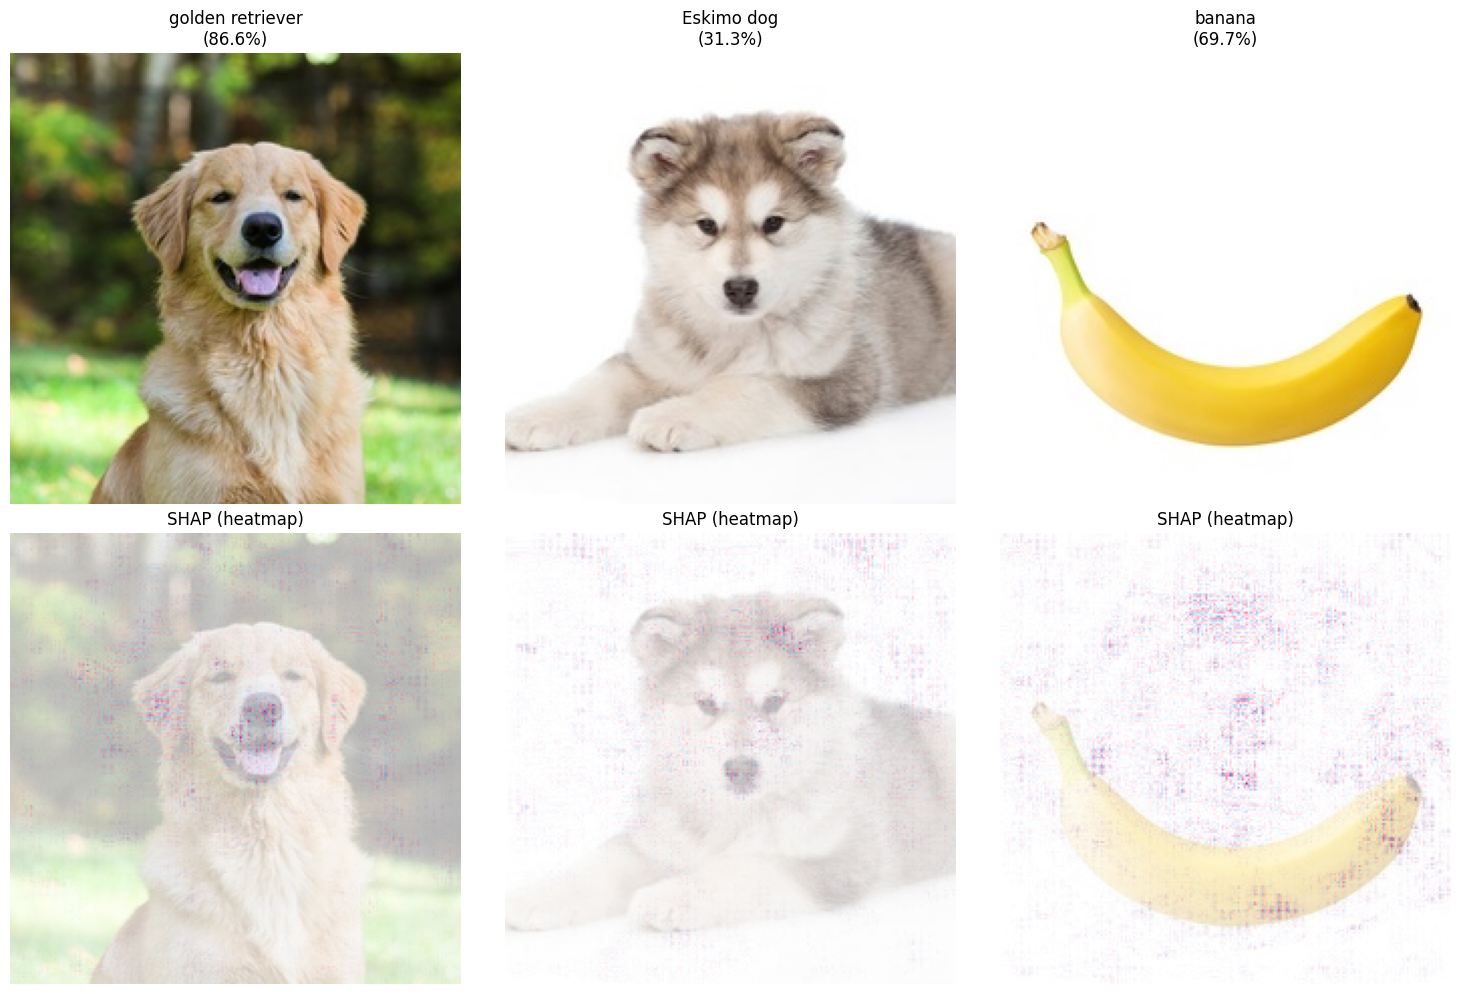

In [20]:
n = len(rutas_imagenes)
fig, ejes = plt.subplots(2, n, figsize=(5 * n, 10))
if n == 1:
    ejes = ejes.reshape(2, 1)

for col, ruta in enumerate(rutas_imagenes):
    imagen, resultados = predecir(ruta)
    _, heatmap = generar_heatmap(ruta)

    print(f"\nImagen: {ruta}")
    for etiqueta, prob in resultados:
        print(f"  {etiqueta:25s} {prob * 100:5.2f}%")

    etiqueta_top, prob_top = resultados[0]

    ejes[0, col].imshow(imagen)
    ejes[0, col].set_title(f"{etiqueta_top}\n({prob_top * 100:.1f}%)")
    ejes[0, col].axis("off")

    # Escala simétrica alrededor de 0: rojo = a favor de la clase,
    # azul = en contra, igual que shap.image_plot.
    limite = np.abs(heatmap).max() + 1e-8
    ejes[1, col].imshow(imagen,alpha=0.3)
    ejes[1, col].imshow(
        heatmap,
        cmap=shap.plots.colors.red_transparent_blue,
        vmin=-limite,
        vmax=limite,
    )
    ejes[1, col].set_title("SHAP (heatmap)")
    ejes[1, col].axis("off")

plt.tight_layout()
plt.show()

----
# Diseño de Loop
Para realizar el documento final del paper en latex, se diseño el siguiente prompt para insertar como `AGENTS.md` dentro del proyecto con Codex para desarrollar exactamente lo que se tenia en mente para este laboratorio.

## Loop :
El proposito de esta sesion es concluir con un paper redactado en latex
sobre los resultados y afirmaciones resultantes de un analisis SHAP sobre
el modelo de clasificacion. El modelo es mobilenetv3_small_050.lamb_in1k y se probo frente a imagene de un perro Golden Retreiver, un Siberian Husky bebe y una banana representativos de las imagenes de prueba 1 2 y 3. Asimismo, se realizo un heatmap para observar los pixeles de mayor influencia. Se puede ver en las imagenes de los perrors que el modelo asigna mayor peso a las areas como la nariz, las orejas, los ojos. Tambien
es interesante que el contorno tiene absolutamente 0 peso, al punto que el heatmap los mostro en 0. Esto sin embargo nos deja observar el mecanismo y as areas de interes de estas categorias. incluso en la imagen 2 donde confundio la raza del perro por Eskimo y Malamute, estuvo muy cerca e identifico la naturaleza canina de la imagen. Por ultimo, el heatmap del banano mostro
que las areas de influencia se miran casi aleatorias, no se define el contorno y no hay un enfoque en areas como las lineas o el tallo, sin embargo, lo clasifico correctamente.

Los resultados fueron:
```
Imagen: images/prueba1.jpg
  golden retriever          86.55%
  Labrador retriever         1.80%
  kuvasz                     1.40%
  Norfolk terrier            1.18%
  Rhodesian ridgeback        0.44%

Imagen: images/prueba2.jpg
  Eskimo dog                31.30%
  malamute                  25.87%
  Siberian husky            12.08%
  Arctic fox                 5.50%
  collie                     2.01%

Imagen: images/prueba3.jpg
  banana                    69.71%
  spaghetti squash           5.40%
  sunglass                   1.05%
  lemon                      1.01%
  whistle                    0.79%
```

El Paper debe estar redactado en latex y tener los siguientes capitulos:
Titulo, Abstract, Introduccion, Metodologia, Resultados, Conclusiones y Referencias.
El estilo debe ser minimalista pero concordante con la estructura de un articulo
en latex: paginas numeradas, 2 columnas de texto, imagenes y tablas correctamente identificadas
y referencias bibliograficas en formato APA.

Asimismo te proveo una lista de las imagenes para que puedas enlazarlas dentro del
archivo tex
```
./images/prueba1.png (golden retreiver)
./images/prueba2.jpg (husky bebe)
./images/prueba3.jpg (banana)
./images/output.png (heatmap SHAP)
```

## Flujo
Trabajaras en un Loop comenzando por una etapa de semilla y continuando
con los pasos siguientes regresando al 1 luego de completar el 4 hasta cumplir
los requisitos de aceptacion.

0. Borrador de contenido y plantilla: realizar la plantilla en latex con
las secciones definidas y con puntos claves relevantes a cada seccion. Esto
servira como semilla para el resto del loop.

1. Verificacion de validez y pertinencia: verificar que el contenido redactado 
sea valido y concordante con las pruebas, que sea valido y pertenezca a su apartado
correspondiente.

2. Coherencia y atribucion: revisar que el paper sea coherente y tenga un flujo
legible de redaccion y que las citas y referencias esten correctamente atribuidas y citadas.

3. Test con latex: probar la renderizacion con latex al archivo main.tex principal
y resolver todos los errores semanticos o programaticos para que compile correctamente y
el estilo concuerde con lo deseado.

4. Redaccion: redaccion de nuevos puntos que consideres relevantes o que sean vacios
en lo discutido y verificacion de que el Abstract sea conistente con las conclusiones.

Los criterios de aceptacion para finalizar la ejecucion del loop son los siguientes
- Redaccion formal y cientifica
- Contenido coherente y relevante
- Titulo breve y explicativo
- Al menos 2 citas formales con APA.
- Inclusion de la tabla de resultados y al menos 2 de las imagenes provistas
- Los capitulos de: Abstract, Introduccion, Metodologia, Resultados, Conclusiones y Referencias.
- Renderizacion en latex sin errores.


 
 

## Prompt semilla
"Desarrolla el paper en latex como descrito en tus instrucciones de agentes"

El resultado mostrado es el producto final desarrollado por la inteligencia artificial gpt-6-astra con el prompt asignado y acceso al `main.ipynb`